# **Build Custom Object Detector with Detectron2**

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

- **INSTALLING ROBOFLOW**

In [1]:
!pip install roboflow

- **INSTALLING DETECTRON2**

In [2]:
!python -m pip install pyyaml==5.1
import sys,os,distutils.core

# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
# Remove existing directory if we need to re-run the cell
!rm -rf detectron2
!git clone 'https://github.com/facebookresearch/detectron2'

dist = distutils.core.run_setup('./detectron2/setup.py')
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0,os.path.abspath('./detectron2'))

  Using cached PyYAML-5.1.tar.gz (274 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 16057, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 16057 (delta 25), reused 8 (delta 8), pack-reused 16016 (from 3)
Receiving objects: 100% (16057/16057), 6.83 MiB | 6.70 MiB/s, done.
Resolving deltas: 100% (11377/11377), done.


In [ ]:
import torch,detectron2
!nvcc --version

print(f"\nTORCH_VERSION: {'.'.join(torch.__version__.split('.')[:2])}\nCUDA_VERSION: {torch.__version__.split('+')[-1]}\nDETECTRON_VERSION: {detectron2.__version__}")


- **IMPORTS**

In [3]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os,json,cv2,random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog

- **Let's get Our Dataset**

- **[DATASET LINK](https://universe.roboflow.com/tobias-price-lane-detection-solid-and-dashed/lane-detection-segmentation-edyqp/dataset/7)**

In [4]:
from google.colab import userdata
API_KEY=userdata.get('RF')

from roboflow import Roboflow
rf = Roboflow(api_key=API_KEY)
project = rf.workspace("tobias-price-lane-detection-solid-and-dashed").project("lane-detection-segmentation-edyqp")
version = project.version(7)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lane-Detection-(Segmentation)-7 in coco-segmentation:: 100%|██████████| 1618/1618 [00:00<00:00, 7585.62it/s]


In [5]:
!pwd

/content


In [6]:
%cd /content/Lane-Detection-Segmentation-7

/content/Lane-Detection-Segmentation-7


In [7]:
!cat /content/Lane-Detection-Segmentation-7/train/_annotations.coco.json

{"info":{"year":"2024","version":"7","description":"Exported from roboflow.com","contributor":"","url":"https://public.roboflow.com/object-detection/undefined","date_created":"2024-05-13T12:28:10+00:00"},"licenses":[{"id":1,"url":"https://creativecommons.org/licenses/by/4.0/","name":"CC BY 4.0"}],"categories":[{"id":0,"name":"Lane-Markings","supercategory":"none"},{"id":1,"name":"Left Boundary -Dashed-","supercategory":"Lane-Markings"},{"id":2,"name":"Left Boundary -Solid-","supercategory":"Lane-Markings"},{"id":3,"name":"Right Boundary -Dashed-","supercategory":"Lane-Markings"},{"id":4,"name":"Right Boundary -Solid-","supercategory":"Lane-Markings"}],"images":[{"id":0,"license":1,"file_name":"yt-oVStntQpKw0-0008_jpg.rf.8acd6aad42ef51ea92aea74c8406419c.jpg","height":360,"width":640,"date_captured":"2024-05-13T12:28:10+00:00","extra":{"user_tags":["youtube:oVStntQpKw0"]}},{"id":1,"license":1,"file_name":"yt-DD_cq9JSeq8-0037_jpg.rf.8e84bd3d8d6b7cda31f07b67758f983c.jpg","height":360,"widt

In [8]:
!pwd

/content/Lane-Detection-Segmentation-7


- **Register Dataset**

In [9]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("exp_train",{},"/content/Lane-Detection-Segmentation-7/train/_annotations.coco.json","/content/Lane-Detection-Segmentation-7/train")
register_coco_instances("exp_valid",{},"/content/Lane-Detection-Segmentation-7/valid/_annotations.coco.json","/content/Lane-Detection-Segmentation-7/valid")
register_coco_instances("exp_test",{},"/content/Lane-Detection-Segmentation-7/test/_annotations.coco.json","/content/Lane-Detection-Segmentation-7/test")

- **VISUALIZING TRAINING DATA**

WARNING [09/11 08:56:55 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/11 08:56:55 d2.data.datasets.coco]: Loaded 1141 images in COCO format from /content/Lane-Detection-Segmentation-7/train/_annotations.coco.json


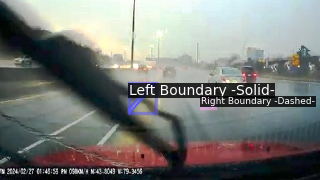

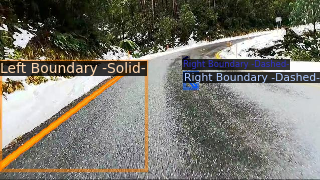

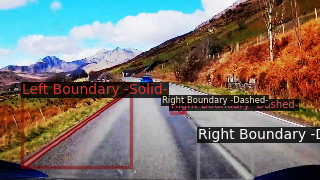

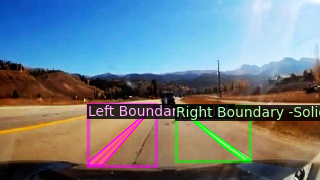

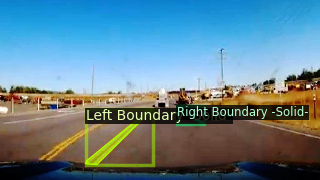

In [11]:
train_metadata = MetadataCatalog.get("exp_train")
dataset_dict = DatasetCatalog.get("exp_train")

for d in random.sample(dataset_dict,5):
  im = cv2.imread(d['file_name'])
  vis = Visualizer(im[:,:,::-1],metadata=train_metadata,scale=0.5)
  v = vis.draw_dataset_dict(d)
  cv2_imshow(v.get_image()[:,:,::-1])

- **TRAINING**

In [13]:
cfg = get_cfg()

# Load the Mask R-CNN architecture
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# setup datasets
cfg.DATASETS.TRAIN = ("exp_train",)
cfg.DATASETS.TEST = ("exp_test",)
cfg.DATALOADER.NUM_WORKERS = 2

# Load pre-trained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Hyperparameter
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0025
cfg.SOLVER.MAX_ITER = 1000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4

# Initialize trainer
os.makedirs(cfg.OUTPUT_DIR,exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[09/11 09:03:35 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:02, 76.5MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[09/11 09:03:38 d2.engine.train_loop]: Starting training from iteration 0


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
W0911 09:03:40.924000 15624 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[09/11 09:03:50 d2.utils.events]:  eta: 0:07:41  iter: 19  total_loss: 2.239  loss_cls: 1.347  loss_box_reg: 0.09646  loss_mask: 0.6906  loss_rpn_cls: 0.1119  loss_rpn_loc: 0.0199    time: 0.4608  last_time: 0.4782  data_time: 0.0152  last_data_time: 0.0057   lr: 4.9952e-05  max_mem: 2581M
[09/11 09:04:05 d2.utils.events]:  eta: 0:07:49  iter: 39  total_loss: 1.685  loss_cls: 0.6162  loss_box_reg: 0.1749  loss_mask: 0.6156  loss_rpn_cls: 0.1423  loss_rpn_loc: 0.02628    time: 0.4776  last_time: 0.4894  data_time: 0.0094  last_data_time: 0.0062   lr: 9.9902e-05  max_mem: 2581M
[09/11 09:04:15 d2.utils.events]:  eta: 0:07:42  iter: 59  total_loss: 1.362  loss_cls: 0.4388  loss_box_reg: 0.4414  loss_mask: 0.4836  loss_rpn_cls: 0.04604  loss_rpn_loc: 0.01748    time: 0.4832  last_time: 0.5259  data_time: 0.0104  last_data_time: 0.0169   lr: 0.00014985  max_mem: 2582M
[09/11 09:04:25 d2.utils.events]:  eta: 0:07:38  iter: 79  total_loss: 1.571  loss_cls: 0.4957  loss_box_reg: 0.556  loss_ma

- **TESTING**

In [15]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR,'model_final.pth')
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("exp_test",)
predictor = DefaultPredictor(cfg)

[09/11 09:14:22 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


- **VISUALIZING RESULT**

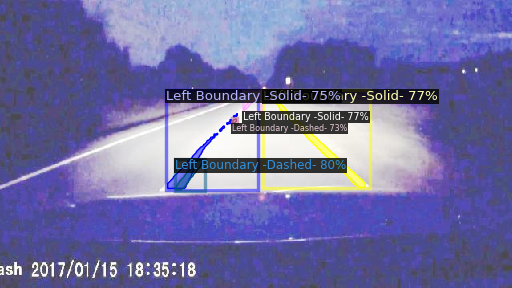

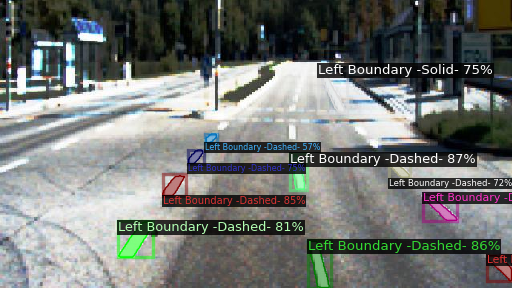

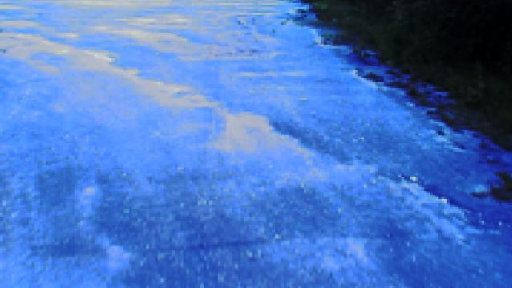

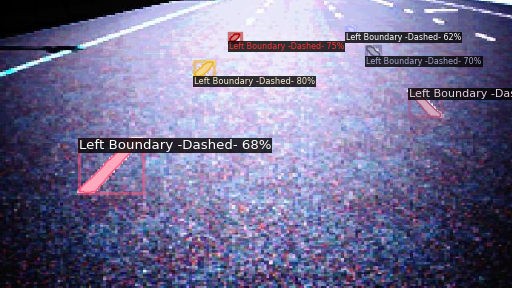

In [18]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,4):
  im = cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])


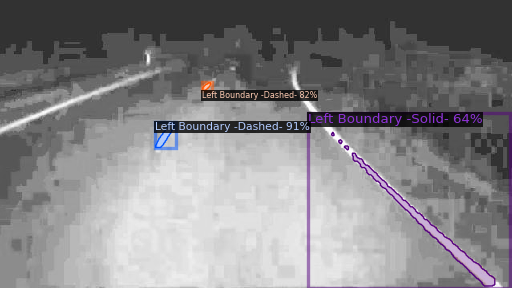

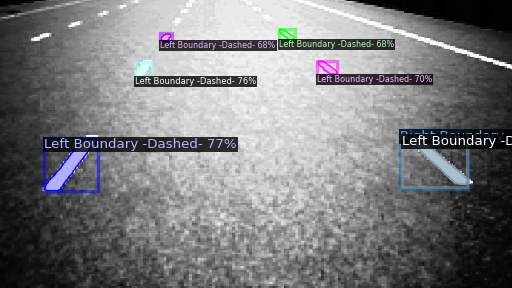

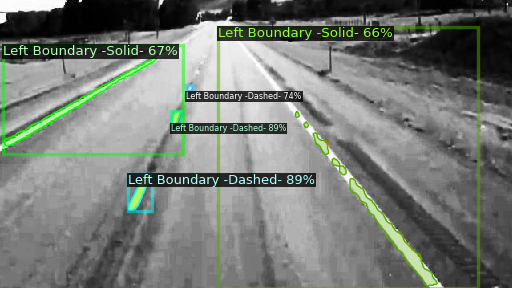

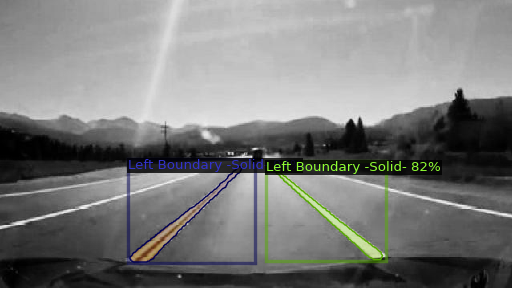

In [20]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,4):
  im = cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8,
      instance_mode = ColorMode.IMAGE_BW
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])


- **EVALUATING**

In [21]:
from detectron2.evaluation import COCOEvaluator,inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("exp_test",output_dir='./output')
val_loader = build_detection_test_loader(cfg,"exp_test")
print(inference_on_dataset(predictor.model,val_loader,evaluator))

[09/11 09:15:32 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [09/11 09:15:32 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/11 09:15:32 d2.data.datasets.coco]: Loaded 151 images in COCO format from /content/Lane-Detection-Segmentation-7/test/_annotations.coco.json
[09/11 09:15:32 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[09/11 09:15:32 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[09/11 09:15:32 d2.data.common]: Serializing 151 elements to byte tensors and concatenating them all ...
[09/11 09:15:32 d2.data.common]: Serialized dataset takes 0.13 MiB
[09/11 09:15:32 d2.evaluation.evaluator]: Start inference on 151 batches
[09/11 09:15:33 d2.evaluation.evaluator]: Inference done 11/15

- **GET THE CONFIG FILE**

In [22]:
f = open('config.yaml','w')
f.write(cfg.dump())
f.close()